# Toxic Comments Classification - LR

#### Author: SAFAA ENNACIRI - ENNS11538307                                 
#### Research Director: M. HAKIM LOUNIS

Dataset: JgsawToxic dataset is a dataset of comments from Wikipedia’s talk page edits. It is avaialble at Kaggle (https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge/data). 


The comments are divided in two classes: toxic and normal.

Algorithme used: LR

Preprocessing techniques used:
* Convert text to lowercase
* Remove emojis and emoticons
* Remove stop words
* Tokenization (accept all kind of tokens except spaces (returns, line breaks, tabs and multiple spaces))

# 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn import metrics
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, cross_val_predict
from matplotlib import pyplot as plt 
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import pickle
import openpyxl 
from openpyxl import Workbook
from openpyxl.styles import Alignment
from openpyxl.styles.borders import Border, Side

# 2. Data Preparation 

In [2]:
# Load training data
df = pd.read_csv('../../Data/train_set1.csv')
df.head()

,id,comment_text,tox
0,20ca7bad20d4c3d1,"You're an asshole, useless piece of shit. Get ...",1
1,72428510d4205ccf,Nonito Donaire \n\nIt is clearly stated in the...,0
2,f3890d4a31f0d45a,"Okay, in the future I shall no longer use the ...",0
3,29ac5b2897f7ef59,fuck off \n\ndon't fuck with me . fuck off,1
4,6f2278059a63256a,"""*E-dog, on another page, you wrote: \n\nThank...",1


In [3]:
# Load testing data
test = pd.read_csv('../../Data/test_set1.csv')
test.head()

,id,comment_text,tox
0,b28eeb594e5ac00f,"AAAAWWWW, widdle wikinazis banned me.\n\nMaybe...",1
1,2f3c460abcd5479f,very crocker sucks n e g r o c o c k s i n h e...,1
2,dc3ae57fa0c30d8d,He lied on my RFC too. He's a liar.,1
3,5eb7bb36f870d2b9,"""I've removed the following:\n""""Morro Bay is a...",0
4,e9c9d9abd37bca1d,Briefcase\n\nToo much importance is given to t...,0


# 3. Preprocessing

In [4]:
import pickle, re

# load file  
with open('../../Data/Emoji_Dict.p', 'rb') as fp:
    Emoji_Dict = pickle.load(fp)
Emoji_Dict = {v: k for k, v in Emoji_Dict.items()}

#remove empjis
def remove_emojis(text):
    for emoj in Emoji_Dict:
        text = re.sub(r'('+emoj+')', " ", text)
    return text

In [5]:
# load file
with open('../../Data/Emoticon_Dict.p', 'rb') as fl:
    Emoticon_Dict = pickle.load(fl)

# remove emoticons
def remove_emoticons(text):
    emoticon_pattern = re.compile(u'(' + u'|'.join(k for k in Emoticon_Dict) + u')')
    return emoticon_pattern.sub(r'', text)

In [6]:
stop_words = set(stopwords.words('english'))

In [7]:
print(stop_words)

{'yours', 'me', 'with', 'under', 'it', 'again', 'own', 'you', 'hadn', 'at', 'very', 't', 'ain', 'further', 'o', 'i', 'theirs', "doesn't", 'as', 'they', 'themselves', 'once', 'shouldn', 'or', 'wouldn', 'this', 'while', 'from', 'she', 'll', 'why', 'hasn', 'ourselves', 'are', 'was', 'up', 'too', 'his', 'of', 'should', 'there', 'their', 'by', 'isn', 'its', 'about', 'been', 've', "hadn't", 'off', 'where', 'down', "haven't", 'what', 'above', "hasn't", 'a', 'against', 'didn', 'so', "isn't", 'no', 'y', "weren't", 'yourself', 'any', 'more', 'out', 'did', 'ours', "wasn't", "you've", 'until', "needn't", "that'll", 'how', 'couldn', "mightn't", 'itself', 'had', 'haven', "mustn't", 'your', 'these', 'is', "don't", 'after', 'most', 'below', "you'll", 'have', 'because', 'he', 'has', 'an', 'my', 'into', 'being', 'some', 'd', 'than', 'am', 'our', 'the', 'during', 'them', 'herself', 'will', 'needn', 'weren', 'to', 'having', 'wasn', 'same', 'only', 'yourselves', "it's", 'her', 'just', 'm', "didn't", 'won',

In [8]:
def clean_text(comment): 

    comment = comment.lower() # Normalize to lowercase 
    comment = remove_emojis(comment) # remove emojis
    comment = remove_emoticons(comment) # remove emoticons
            
    word_tokens = comment.split(' ') #word_tokenize(comment)
    
    filtered_comment = []  
    # converts the words in word_tokens tand tchecks whether 
    #they are present in stop_words or not
    for w in word_tokens:
        if w not in stop_words:
            filtered_comment.append(w)

    comment = (" ").join(filtered_comment)
    
    return comment

In [9]:
# clean and normalize comments
df['comment_text'] = df['comment_text'].map(lambda word:clean_text(word))
test['comment_text'] = test['comment_text'].map(lambda word:clean_text(word))

In [10]:
x_train = df['comment_text']
y_train = df['tox']

#Check shape of data
print(x_train.shape)
print(y_train.shape)

(25960,)
(25960,)


In [11]:
X_test = test['comment_text']
Y_test = test['tox']

#Check shape of data
print(X_test.shape)
print(Y_test.shape)

(6490,)
(6490,)


# 3. Classifier training (LR)

### Create pipeline

In [12]:
# create a pipeline
model_pipeline = Pipeline([
                ('tfidf', TfidfVectorizer(lowercase=False, 
                                          token_pattern=r'\S+', max_features=20000)),
                ('clf', LogisticRegression(max_iter=1000, random_state=0, verbose=True, C=10,
                                           class_weight='balanced', penalty='l1', solver='saga'))])

### Train classifier

In [13]:
# cross validation
metrics = ['accuracy', 'recall', 'f1', 'precision']
result = cross_validate (model_pipeline, x_train, y_train, cv=5, scoring = metrics,  return_estimator=True)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


convergence after 992 epochs took 707 seconds


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed: 11.8min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


max_iter reached after 707 seconds


/home/laboratoire/.pyenv/versions/3.7.8/envs/labo/lib/python3.7/site-packages/sklearn/linear_model/_sag.py:354: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  ConvergenceWarning,
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed: 11.8min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


...

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  9.7min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


convergence after 911 epochs took 653 seconds


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed: 10.9min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


convergence after 983 epochs took 694 seconds


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed: 11.6min finished


In [14]:
# save models
svc_fit = result['estimator']
i = 0
for model in svc_fit:
    dir_name = "models/Set1_approach#17_" + str(i) + ".sav"
    pickle.dump(model, open(dir_name, 'wb'))
    i = i + 1

### Evaluate metrics

In [15]:
# Model Evaluation metrics for train data
train_accuracy = "%.4f" % (result['test_accuracy'].mean())
train_recall  = "%.4f" % (result['test_recall'].mean())
train_F1_score  = "%.4f" % (result['test_f1'].mean())
train_precision  = "%.4f" % (result['test_precision'].mean())

# Print scores for evaluation metrics
print('Results for train data')
print ('-----------------------')
print('Accuracy score : ', train_accuracy)
print('recall : ', train_recall)
print('F1_score : ' , train_F1_score)
print('precision : ' , train_precision)

Results for train data
-----------------------
Accuracy score :  0.8682
recall :  0.8404
F1_score :  0.8642
precision :  0.8894


# 4. Predictions

### Test set

In [16]:
# predict test data
preds_test = cross_val_predict(model_pipeline, X_test, Y_test, cv=5)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


convergence after 959 epochs took 72 seconds


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  1.2min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


convergence after 891 epochs took 65 seconds


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  1.1min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


...

/home/laboratoire/.pyenv/versions/3.7.8/envs/labo/lib/python3.7/site-packages/sklearn/linear_model/_sag.py:354: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  ConvergenceWarning,
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  1.2min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


convergence after 803 epochs took 57 seconds


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   57.3s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


convergence after 792 epochs took 59 seconds


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   59.0s finished


In [17]:
# svm Confusion matrix
print('\n confusion matrix for test data \n')
print((confusion_matrix(Y_test, preds_test)))


 confusion matrix for test data 

[[2832  389]
 [ 710 2559]]


In [18]:
# svm classification report
print('\n\n classification report for test data \n')
print(classification_report(Y_test, preds_test, target_names=['normal','toxic']))



 classification report for test data 

              precision    recall  f1-score   support

      normal       0.80      0.88      0.84      3221
       toxic       0.87      0.78      0.82      3269

    accuracy                           0.83      6490
   macro avg       0.83      0.83      0.83      6490
weighted avg       0.83      0.83      0.83      6490



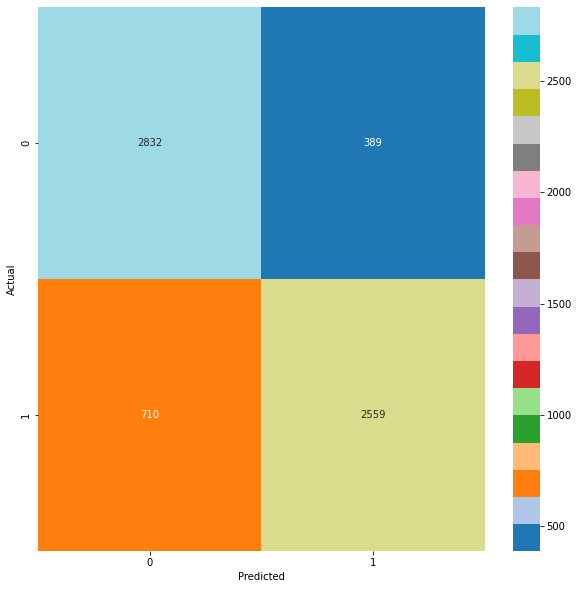

In [19]:
# plot confusion matrix
conf_mat = confusion_matrix(Y_test, preds_test)
fig, ax = plt.subplots(figsize=(10,10))
cmap = "tab20"
sns.heatmap(conf_mat, annot=True, fmt='d',cmap=cmap)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [20]:
# Model Evaluation metrics for test data
test_accuracy = "%.4f" % (accuracy_score(Y_test, preds_test))
test_recall  = "%.4f" % (recall_score(Y_test, preds_test))
test_F1_score  = "%.4f" % (f1_score(Y_test, preds_test))
test_precision  = "%.4f" % (precision_score(Y_test, preds_test))

# Print scores for evaluation metrics
print('Results for test data')
print ('-----------------------')
print('Accuracy score : ', test_accuracy)
print('recall : ', test_recall)
print('F1_score : ' , test_F1_score)
print('precision : ' , test_precision)

Results for test data
-----------------------
Accuracy score :  0.8307
recall :  0.7828
F1_score :  0.8232
precision :  0.8680


# 5. Save results to Excel file

In [21]:
# define tarjet
newFile = "../results_LR_set1.xlsx"

# open excel file
workbook = openpyxl.load_workbook(filename = newFile)        
worksheet = workbook.active
    
# scores for evaluation metrics
data = {1:'Approach #17', 2:train_accuracy, 3:train_recall, 4:train_F1_score, 5:train_precision, 
                  6:test_accuracy, 7:test_recall, 8:test_F1_score, 9:test_precision}

# row's index for approach
index = 19

# delete row of approach
worksheet.delete_rows(index, 1)

# insert data in excel sheet
worksheet.insert_rows(index)
for col, value in data.items():
    worksheet.cell(row=index, column=col, value=value)
    
# define style border
thin_border = Border(left=Side(style='thin'), 
                     right=Side(style='thin'), 
                     top=Side(style='thin'), 
                     bottom=Side(style='thin'))
cell_alignment = Alignment(horizontal='center')

# apply style border
for row in worksheet:
    for cell in row:
        cell.border = thin_border
        cell.alignment = cell_alignment
    
# save file
workbook.save(newFile)